# Clustering analysis

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

from anomaly.plot import add_line_indicators
from anomaly.plot import spec_photo_thumbnail
from anomaly.utils import get_sdss_spec_img
from anomaly.constants import SDSS_NEBULAR_LINES_RATIOS_NAMES
from astroExplain.spectra.astronomy import BPT, get_subclass_summary
from astroExplain.spectra import clustering
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data igestion

In [2]:
def load_xai(run_id: str, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "unique_norm_weights": None,
        "norm_unique_norm_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["unique_norm_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["norm_weights"], n_segments=n_segments
    )

    data_dict["norm_unique_norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_norm_weights"]
    )

    return data_dict

## Top ranked explanations

In [4]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    download_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
    skip_ranks_list=[-1],
):

    lw = 0.75

    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):

        if anomaly_rank == n_top_ranked:
            break
        if anomaly_rank + 1 in skip_ranks_list:
            print(f"Skipping rank {anomaly_rank + 1}.", end="\r")
            continue

        print(f"Explanation for anomaly rank {anomaly_rank + 1}", end="\r")

        specobjid = metadata_df.index[anomaly_rank]

        if download_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values

                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_rank]

        norm_weights_spec = norm_weights[anomaly_rank]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(20, 7),
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black", linewidth=lw)
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black",
            label=f"Cluster {cluster_id}", linewidth=lw
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 0.4)
        y_ticks = np.arange(0, 0.41, 0.1)
        axs[1].set_yticks(y_ticks)

        if download_images is True:
            image_name = f"image_{specobjid}.jpeg"
        # Load the image
            img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

            # Create inset in top-right corner of axs[0]
            width_height_image = 1
            axins = inset_axes(
                axs[0],
                width=width_height_image,
                height=width_height_image,
                bbox_to_anchor=(1.01, 1.02),
                bbox_transform=axs[0].transAxes,
                loc="upper right",
            )

            # Show image in the inset
            axins.imshow(img)
            axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

## Explanations

In [5]:
run_ids_343_50k_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9'
}

In [6]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607200003_uniform_343_samples_100000_scale_0.9',
    'iforest': 'xai_202607201307_uniform_343_samples_100000_scale_0.9'
}

# Config

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_6_dir = f"{thesis_dir}/chapters/06_figures"

## Constants

In [8]:
score_name = "mse"
bin_id = "bin_03"
n_segments = 343
n_clusters = 6

kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}"
kmeans_model_name = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_name}")

Model ID: kmeans_6_clusters_343_segments


## Data

In [9]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

## Explanations

In [10]:
n_samples = 100_000

if n_samples == 100_000:
    run_ids_dict = run_ids_343_dict
elif n_samples == 50_000:
    run_ids_dict = run_ids_343_50k_dict

run_id = run_ids_dict[score_name]

load_from = f"{explanations_dir}/{bin_id}/{score_name}"

print(f"Loading XAI data from: {load_from}")

(
    anomalies_arr,
    specobjids_arr,
    weights_arr,
) = load_xai(run_id=run_id, load_from=load_from)


Loading XAI data from: /home/elom/phd/code/explanations/bin_03/mse


## Order explanations according to score

In [11]:
scores_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    usecols=["specobjid", score_name],
    index_col="specobjid",
).loc[specobjids_arr]

sorted_specobjids_arr = scores_df[score_name].sort_values(
    ascending=False
).index.to_numpy()

# 1. Find the index mapping from specobjids_arr to sorted_specobjids_arr
indexer = pd.Index(specobjids_arr).get_indexer(sorted_specobjids_arr)

# 2. Reorder all three arrays simultaneously using the indexer
specobjids_arr = specobjids_arr[indexer]
anomalies_arr = anomalies_arr[indexer]
weights_arr = weights_arr[indexer]

weights_dict = weights_prep(
    weights=weights_arr, n_segments=n_segments
)

scores_df.loc[specobjids_arr].head(5)

,mse
specobjid,
407596690535639040,51.269002
1413149843194406912,46.845534
378399434137954304,45.943604
1767703038748813312,45.294575
2930814289679771648,44.142569


# K-means model
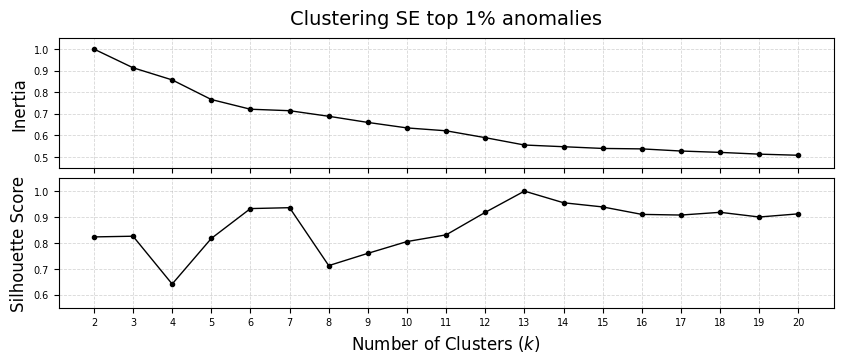

## Train data

In [12]:
X = weights_dict["norm_unique_norm_weights"]

## Train and save

In [13]:
# ```python
start_time = time.perf_counter()

kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(X)
end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
# ```

# ```python
# # train time: 0.17 seconds
# # ['/home/elom/phd/code/clustering/bin_03/mse//kmeans_6_clusters_343_segments.joblib']
# ```

train time: 0.19 seconds


['/home/elom/phd/code/clustering/bin_03/mse/kmeans_6_clusters_343_segments.joblib']

## Save metadata

In [14]:
# ```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.predict(X)

cluster_meta_df = meta_with_ratios_df.loc[specobjids_arr].copy()
cluster_meta_df["cluster"] = cluster_labels

# append score, specobjids_arr is already sorted by score
cluster_meta_df[score_name] = scores_df[score_name].loc[specobjids_arr].copy()
cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")
# ```

# Clusters metadata

In [15]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.predict(X)

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=weights_dict["norm_weights"],
    print_n_clusters=True,
)

weights_dict["spectra_cluster_dict"] = spectra_cluster_dict
weights_dict["weights_cluster_dict"] = weights_cluster_dict


weights_dict["centroids"] = kmeans_model.cluster_centers_
# 0;408
# 1;540
# 2;288
# 3;268
# 4;304
# 5;11

0;408
1;540
2;288
3;268
4;304
5;11


In [16]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
).loc[specobjids_arr]


# Line ratios

## Median line ratios

In [17]:
median_cluster_ratios_df = pd.DataFrame(
    index=range(0, n_clusters),
    columns=SDSS_NEBULAR_LINES_RATIOS_NAMES,
)
for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        cluster_meta_df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        cluster_meta_df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_density_ratio"]
    )
# map col name by replacing the '_' with ' ' for better readability
median_cluster_ratios_df.columns = [
    col.replace("_", " ") for col in median_cluster_ratios_df.columns
]

median_cluster_ratios_df.to_clipboard(excel=True, index=True)
median_cluster_ratios_df

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
0,3.748319,0.409706,1.387313,1.236246,0.330914,1.359598,0.582592
1,3.795329,0.248739,1.38852,1.272412,0.249302,1.347979,0.721755
2,4.158723,0.478891,1.135001,1.315719,0.299656,1.257105,0.438656
3,3.476272,0.124339,3.69105,3.908726,0.225046,1.345153,1.335211
4,3.3487,0.151872,1.846447,1.334979,0.263048,1.389719,1.080119
5,3.580772,0.831059,1.614317,0.611927,0.422282,1.385509,0.223745


## Cluster 0 ratios percentiles

In [18]:
cluster_mask = cluster_meta_df["cluster"] == 0
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df.T.to_clipboard(excel=True, index=True)
ratios_percentiles_df.T

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
45th,3.621760,0.370434,1.169369,1.070667,0.315909,1.343743,0.504025
50th,3.748319,0.409706,1.387313,1.236246,0.330914,1.359598,0.582592
55th,3.851186,0.471654,1.668439,1.373117,0.344922,1.378721,0.665055


## Cluster 1 ratios percentiles

In [19]:
cluster_mask = cluster_meta_df["cluster"] == 1
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df.T.to_clipboard(excel=True, index=True)
ratios_percentiles_df.T

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
45th,3.701747,0.227310,1.279288,1.174278,0.240099,1.336275,0.642140
50th,3.795329,0.248739,1.388520,1.272412,0.249302,1.347979,0.721755
55th,3.854598,0.267406,1.544875,1.380417,0.257709,1.356433,0.794518


## Cluster 2 percentiles

In [20]:
cluster_mask = cluster_meta_df["cluster"] == 2
percentiles = np.arange(0.45, 0.6, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df.T.to_clipboard(excel=True, index=True)
ratios_percentiles_df.T

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
45th,4.065209,0.433916,1.005109,1.099021,0.285458,1.241386,0.373414
50th,4.158723,0.478891,1.135001,1.315719,0.299656,1.257105,0.438656
55th,4.251897,0.514431,1.326386,1.539738,0.313069,1.270817,0.502382


## Cluster 3 ratios percentiles

In [21]:
cluster_mask = cluster_meta_df["cluster"] == 3
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df.T.to_clipboard(excel=True, index=True)
ratios_percentiles_df.T

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
45th,3.410375,0.114530,3.487660,3.456300,0.212969,1.329832,1.280099
50th,3.476272,0.124339,3.691050,3.908726,0.225046,1.345153,1.335211
55th,3.528410,0.158644,3.900455,4.189765,0.243115,1.358399,1.419166


## Cluster 4 ratios percentiles

In [22]:
cluster_mask = cluster_meta_df["cluster"] == 4
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df.T.to_clipboard(excel=True, index=True)
ratios_percentiles_df.T

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
45th,3.315752,0.140892,1.736266,1.252688,0.251553,1.380456,1.027377
50th,3.348700,0.151872,1.846447,1.334979,0.263048,1.389719,1.080119
55th,3.388143,0.163607,2.005748,1.462596,0.271062,1.398574,1.156284


## Cluster 5 percentiles

In [23]:
cluster_mask = cluster_meta_df["cluster"] == 5
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df.T.to_clipboard(excel=True, index=True)
ratios_percentiles_df.T

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
45th,3.503744,0.709114,1.611027,0.580050,0.375494,1.149640,0.191071
50th,3.580772,0.831059,1.614317,0.611927,0.422282,1.385509,0.223745
55th,3.657800,0.953005,1.617606,0.643804,0.490109,1.399878,0.276873


# Redshift Analysis

In [24]:
z_dict = {"cluster": [], "z_min": [], "z_max": [], "z_mean": [], "z_median": []}

for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id
    z = cluster_meta_df["z"].loc[mask].values

    z_dict["cluster"].append(cluster_id)
    z_dict["z_min"].append(np.min(z))
    z_dict["z_max"].append(np.max(z))
    z_dict["z_mean"].append(np.mean(z))
    z_dict["z_median"].append(np.median(z))
z_df = pd.DataFrame(z_dict)
z_df

,cluster,z_min,z_max,z_mean,z_median
0,0,0.010673,0.262315,0.090362,0.089639
1,1,0.010093,0.261698,0.068517,0.055840
2,2,0.011134,0.271920,0.083456,0.075833
3,3,0.010262,0.234167,0.053717,0.035546
4,4,0.011578,0.179591,0.042405,0.027792
5,5,0.067039,0.089808,0.085675,0.088545


In [25]:
low_wave, upper_wave = 5_565, 5_590
z_df["lower_wave_min"] = low_wave / (1 + z_df["z_min"])
z_df["upper_wave_min"] = upper_wave / (1 + z_df["z_min"])
z_df["lower_wave_max"] = low_wave / (1 + z_df["z_max"])
z_df["upper_wave_max"] = upper_wave / (1 + z_df["z_max"])
z_df["lower_wave_mean"] = low_wave / (1 + z_df["z_mean"])
z_df["upper_wave_mean"] = upper_wave / (1 + z_df["z_mean"])
z_df["lower_wave_median"] = low_wave / (1 + z_df["z_median"])
z_df["upper_wave_median"] = upper_wave / (1 + z_df["z_median"])
z_df

,cluster,z_min,z_max,z_mean,z_median,lower_wave_min,upper_wave_min,lower_wave_max,upper_wave_max,lower_wave_mean,upper_wave_mean,lower_wave_median,upper_wave_median
0,0,0.010673,0.262315,0.090362,0.089639,5506.234165,5530.970168,4408.565054,4428.369928,5103.811464,5126.739637,5107.195584,5130.138961
1,1,0.010093,0.261698,0.068517,0.055840,5509.396417,5534.146625,4410.724441,4430.539016,5208.151117,5231.548022,5270.685177,5294.363008
2,2,0.011134,0.271920,0.083456,0.075833,5503.724177,5528.448904,4375.274831,4394.930153,5136.339973,5159.414277,5172.738105,5195.975922
3,3,0.010262,0.234167,0.053717,0.035546,5508.474568,5533.220635,4509.113149,4529.369722,5281.304631,5305.030168,5373.975926,5398.117777
4,4,0.011578,0.179591,0.042405,0.027792,5501.307240,5526.021109,4717.738510,4738.932304,5338.615019,5362.598016,5414.518142,5438.842122
5,5,0.067039,0.089808,0.085675,0.088545,5215.368428,5238.797756,5106.404064,5129.343884,5125.845717,5148.872877,5112.326917,5135.293345


# Clusters' XAI

## Centroid & Avg Spec

In [26]:
# lw = 0.75
# for label, centroid in enumerate(weights_dict["centroids"]):

#     fig, axs = plt.subplots(
#         nrows=2,
#         ncols=1,
#         figsize=(20, 7),
#         sharex=True,
#         sharey=False,
#     )

#     # set minor ticks on
#     for ax in axs.flatten():
#         ax.minorticks_on()

#     centroid = clustering.expand_weights_per_segments(
#         centroid.reshape(1, -1),
#         wave_nm.size,
#         n_segments,
#     )
#     centroid = clustering.normalize_weights_l2_abs(centroid).reshape(-1)
#     avg_spectrum = weights_dict["spectra_cluster_dict"][label].mean(axis=0)

#     axs[0].plot(
#         wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
#     )
#     axs[0].legend()
#     # weights
#     axs[1].plot(
#         wave_nm, centroid, color="black", label="Centroid explanation", linewidth=lw
#     )
#     axs[1].legend()
#     # set limits
#     # set limits
#     axs[1].set_ylim(0, 0.31)
#     y_ticks = np.arange(0, 0.31, 0.1)
#     axs[1].set_yticks(y_ticks)
#     axs[1].set_xlabel(r"$\lambda$ [nm]")

#     fig.suptitle(
#         f"Cluster {label}",
#         fontsize=12,
#     )

#     plot_name = f"avg_spec_centroid_{label}"

#     save_to = f"{kmeans_model_dir}/avg_spec_centroids"
#     os.makedirs(save_to, exist_ok=True)

#     fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
#     fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
#     plt.clf()
#     plt.close(fig)

## Centroid & Median Spec

In [27]:
# lw = 0.75
# for label, centroid in enumerate(weights_dict["centroids"]):

#     fig, axs = plt.subplots(
#         nrows=2,
#         ncols=1,
#         figsize=(20, 7),
#         sharex=True,
#         sharey=False,
#     )

#     # set minor ticks on
#     for ax in axs.flatten():
#         ax.minorticks_on()

#     centroid = clustering.expand_weights_per_segments(
#         centroid.reshape(1, -1),
#         wave_nm.size,
#         n_segments,
#     )
#     centroid = clustering.normalize_weights_l2_abs(centroid).reshape(-1)
#     _spec = weights_dict["spectra_cluster_dict"][label]
#     med_spec = np.nanmedian(_spec, axis=0)

#     axs[0].plot(
#         wave_nm, med_spec, color="black", label="Median spectrum", linewidth=lw
#     )
#     axs[0].legend()
#     # weights
#     axs[1].plot(
#         wave_nm, centroid, color="black", label="Centroid explanation", linewidth=lw
#     )
#     axs[1].legend()
#     # set limits
#     # set limits
#     axs[1].set_ylim(0, 0.31)
#     y_ticks = np.arange(0, 0.31, 0.1)
#     axs[1].set_yticks(y_ticks)
#     axs[1].set_xlabel(r"$\lambda$ [nm]")

#     fig.suptitle(
#         f"Cluster {label}",
#         fontsize=12,
#     )

#     plot_name = f"median_spec_centroid_{label}"

#     save_to = f"{kmeans_model_dir}/median_spec_centroids"
#     os.makedirs(save_to, exist_ok=True)

#     fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
#     fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
#     plt.clf()
#     plt.close(fig)

## Avg Spec & XAI

In [28]:
# lw = 0.75
# for label_cluster, weights in weights_dict['weights_cluster_dict'].items():

#     fig, axs = plt.subplots(
#         nrows=2,
#         ncols=1,
#         figsize=(20, 7),
#         sharex=True,
#         sharey=False,
#     )

#     # set minor ticks on
#     for ax in axs.flatten():
#         ax.minorticks_on()

#     spec = weights_dict["spectra_cluster_dict"][label_cluster]

#     avg_spectrum = spec.mean(axis=0)
#     avg_weights = weights.mean(axis=0)

#     axs[0].plot(
#         wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
#     )
#     axs[0].legend()
#     # weights
#     axs[1].plot(
#         wave_nm, avg_weights, color="black", label="Average explanation", linewidth=lw
#     )
#     axs[1].legend()
#     # set limits
#     axs[1].set_ylim(0, 0.31)
#     y_ticks = np.arange(0, 0.31, 0.1)
#     axs[1].set_yticks(y_ticks)
#     axs[1].set_xlabel(r"$\lambda$ [nm]")

#     fig.suptitle(
#         f"Cluster {label_cluster}",
#         fontsize=12,
#     )

#     plot_name = f"avg_spec_xai_{label_cluster}"

#     save_to = f"{kmeans_model_dir}/avg_spec_xai"
#     os.makedirs(save_to, exist_ok=True)

#     fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
#     fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
#     plt.clf()
#     plt.close(fig)

## Median Spec & XAI

In [29]:
# lw = 0.75
# for label_cluster, weights in weights_dict['weights_cluster_dict'].items():

#     fig, axs = plt.subplots(
#         nrows=2,
#         ncols=1,
#         figsize=(20, 7),
#         sharex=True,
#         sharey=False,
#     )

#     # set minor ticks on
#     for ax in axs.flatten():
#         ax.minorticks_on()

#     spec = weights_dict["spectra_cluster_dict"][label_cluster]

#     median_spec = np.nanmedian(spec, axis=0)
#     median_weights = np.nanmedian(weights, axis=0)

#     axs[0].plot(
#         wave_nm, median_spec, color="black", label="Median spectrum", linewidth=lw
#     )
#     axs[0].legend()
#     # weights
#     axs[1].plot(
#         wave_nm, median_weights, color="black", label="Median explanation",
#         linewidth=lw
# )
#     axs[1].legend()
#     # set limits
#     axs[1].set_ylim(0, 0.31)
#     y_ticks = np.arange(0, 0.31, 0.1)
#     axs[1].set_yticks(y_ticks)
#     axs[1].set_xlabel(r"$\lambda$ [nm]")

#     fig.suptitle(
#         f"Cluster {label_cluster}",
#         fontsize=12,
#     )

#     plot_name = f"median_spec_xai_{label_cluster}"

#     save_to = f"{kmeans_model_dir}/median_spec_xai"
#     os.makedirs(save_to, exist_ok=True)

#     fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
#     fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
#     plt.clf()
#     plt.close(fig)

# Top ranked anomalies per cluster

In [30]:
# cluster_id = 5

# mask = cluster_meta_df["cluster"] == cluster_id

# metadata_df = cluster_meta_df.loc[mask].sort_values(
#     by=f"{score_name}", ascending=False
# )

# spectra = anomalies_arr[mask]
# norm_weights = weights_dict["norm_weights"][mask]

# plot_top_ranked_explanations(
#     cluster_id=cluster_id,
#     metadata_df=metadata_df,
#     spectra=spectra,
#     norm_weights=norm_weights,
#     wave=wave_nm,
#     kmeans_model_dir=kmeans_model_dir,
#     download_images=True,
#     n_top_ranked=-1,
#     max_norm_weights=False,
#     # skip_ranks_list= list(range(0, 79)) + [79] # for cluster 2
#     # skip_ranks_list=[79] # for cluster 2
# )

## Check ranking

In [31]:
cluster_id = 0
mask = cluster_meta_df["cluster"] == cluster_id
metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)

spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]
metadata_df.loc[:, ["cluster", score_name]].head(10)
# scores_df.loc[mask].head(10)


,cluster,mse
specobjid,,
407596690535639040,0,51.269002
1413149843194406912,0,46.845534
378399434137954304,0,45.943604
1767703038748813312,0,45.294575
1610143844655982592,0,42.411082
407595591024011264,0,38.202324
305239577747023872,0,38.080637
407586794930989056,0,34.455075
2836210386607302656,0,33.200128


In [32]:
anomaly_rank = 0
cluster_id = 0

mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)

n_anomalies_in_cluster = metadata_df.shape[0]
print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

specobjid = metadata_df.index[anomaly_rank]
metadata_df.loc[specobjid, ["cluster", score_name]]

Number of anomalies in cluster 0: 408


cluster            0
mse        51.269002
Name: 407596690535639040, dtype: object

In [33]:
# mask of oiii_to_oii = nan
cluster_id = 4
mask_cluster = cluster_meta_df["cluster"] == cluster_id
mask_oiii_to_oii_nan = cluster_meta_df.loc[mask_cluster]["oiii_to_oii"].isna()
n_nan = mask_oiii_to_oii_nan.sum()
n_total = mask_oiii_to_oii_nan.shape[0]
pct_valid = (n_total - n_nan) / n_total * 100
pct_nan = n_nan / n_total * 100
print(f"Cluster {cluster_id}: {n_nan} out of {n_total} have NaN oiii_to_oii values.\n")
print(f"\t{pct_nan:.0f}% have NaN oiii_to_oii values.")
print(f"\t{pct_valid:.0f}% have valid oiii_to_oii values.")
# specobjid = 3320337450726877184
# cluster_meta_df.loc[
#     specobjid,
#     [
#         'oii_3726_flux', 'oii_3729_flux', 'oiii_4959_flux', 'oiii_5007_flux',
#         'oiii_flux', 'oiii_to_oii'
#     ] + ['z', "cluster", score_name]
# ]

Cluster 4: 103 out of 304 have NaN oiii_to_oii values.

	34% have NaN oiii_to_oii values.
	66% have valid oiii_to_oii values.


# BPT

['(0)', '(1)', '(2)', '(3)', '(4)', '(5)']
[-0.38752737 -0.60425643 -0.31976309 -0.90539198 -0.81852188 -0.0803679 ]
[0.14217459 0.1425521  0.05499638 0.56714998 0.26633696 0.20798873]


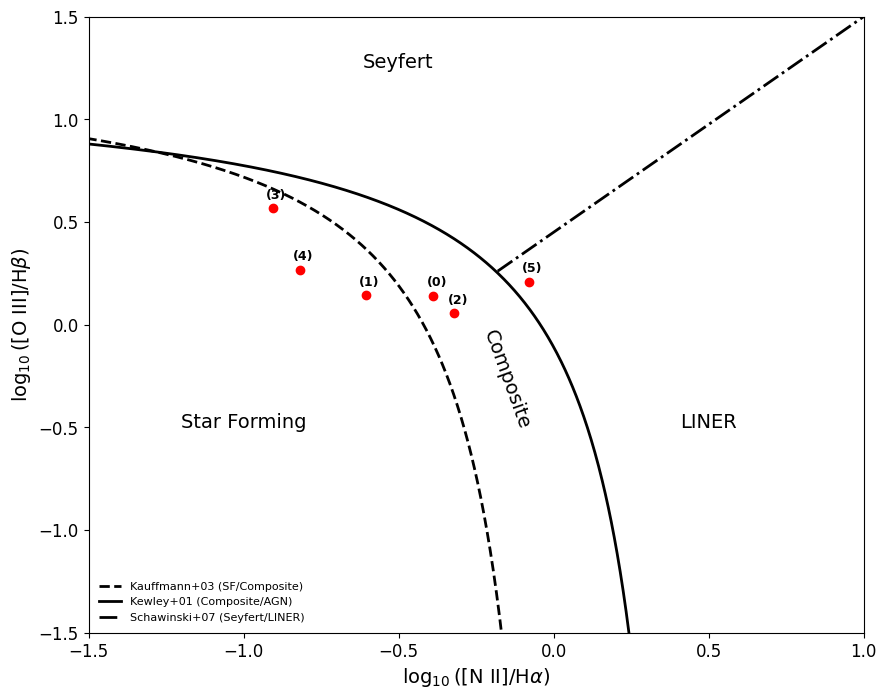

In [34]:
labels = [f"({i})" for i in range(0, n_clusters)]
print(labels)

n2_ha = median_cluster_ratios_df["nii to halpha"].to_list()
o3_hb = median_cluster_ratios_df["oiii to hbeta"].to_list()
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)

print(log_n2_ha)
print(log_o3_hb)

fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = BPT.standar_bpt_plot(fig, ax, log_n2_ha, log_o3_hb, labels, xytext=(-5, 5))

# Cluster 0 & 5

## Data prep

In [35]:
# Cluster 0
weights_0 = weights_dict["weights_cluster_dict"][0]
med_weights_0 = np.nanmedian(weights_0, axis=0)
spec_0 = weights_dict["spectra_cluster_dict"][0]
med_spec_0 = np.nanmedian(spec_0, axis=0)

# Cluster 5
weights_5 = weights_dict["weights_cluster_dict"][5]
med_weights_5 = np.nanmedian(weights_5, axis=0)
spec_5 = weights_dict["spectra_cluster_dict"][5]
med_spec_5 = np.nanmedian(spec_5, axis=0)

## Figure

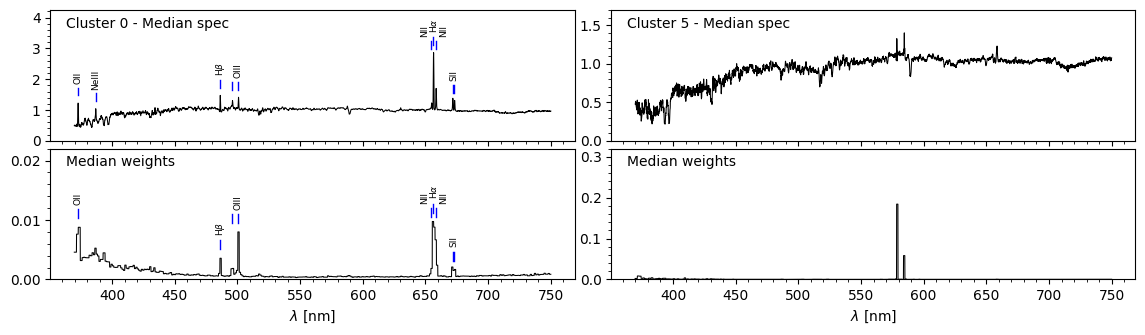

In [36]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(14, 3.5),
    sharex=True,
    sharey=False,
)

# Cluster 0
axs[0, 0].plot(wave_nm, med_spec_0, color="black", linewidth=lw)

y_lims = (0, 4.25)
y_ticks = range(0, 5, 1)
axs[0, 0].set_ylim(y_lims)
axs[0, 0].set_yticks(y_ticks)

top_lines = {
    "indicator_starts": 0.25,
    "indicator_height": 0.25,
    "delta": 1,
    "fontsize": 6.5,
    "active_lines": ['OII', 'NeIII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[0, 0], wave_nm, med_spec_0, **top_lines)

# weights
axs[1, 0].plot(wave_nm, med_weights_0, color="black", linewidth=lw)

bottom_lines = {
    "indicator_starts": 0.0015,
    "indicator_height": 0.0015,
    "delta": 1,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[1, 0], wave_nm, med_weights_0, **bottom_lines)

# ------------------------------------------------------------------
# Cluster 5
axs[0, 1].plot(wave_nm, med_spec_5, color="black", linewidth=lw)
y_lims = (0, 1.7)
y_ticks = np.arange(0, 1.7, 0.5)
axs[0, 1].set_ylim(y_lims)
axs[0, 1].set_yticks(y_ticks)


# weights
axs[1, 1].plot(wave_nm, med_weights_5, color="black", linewidth=lw)
# --------------------------------------------------------------------
y_lims = (0, 0.022)
y_ticks = np.arange(0, 0.025, 0.01)
axs[1, 0].set_ylim(y_lims)
axs[1, 0].set_yticks(y_ticks)

y_lims = (0, 0.32)
y_ticks = np.arange(0, 0.32, 0.1)
axs[1, 1].set_ylim(y_lims)
axs[1, 1].set_yticks(y_ticks)
# wavelength
axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text cluster 0
axs[0, 0].text(
    0.03, 0.95, 'Cluster 0 - Median spec', transform=axs[0, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

axs[1, 0].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

# add text cluster 5
axs[0, 1].text(
    0.03, 0.95, 'Cluster 5 - Median spec', transform=axs[0, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[1, 1].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# # save fig
# fname = 'se_cluster_0_5'
# fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

# Clusters 1-4

## Data prep

In [37]:
# Cluster 1
weights_1 = weights_dict["weights_cluster_dict"][1]
med_weights_1 = np.nanmedian(weights_1, axis=0)
spec_1 = weights_dict["spectra_cluster_dict"][1]
med_spec_1 = np.nanmedian(spec_1, axis=0)

# Cluster 2
weights_2 = weights_dict["weights_cluster_dict"][2]
med_weights_2 = np.nanmedian(weights_2, axis=0)
spec_2 = weights_dict["spectra_cluster_dict"][2]
med_spec_2 = np.nanmedian(spec_2, axis=0)

# Cluster 3
weights_3 = weights_dict["weights_cluster_dict"][3]
med_weights_3 = np.nanmedian(weights_3, axis=0)
spec_3 = weights_dict["spectra_cluster_dict"][3]
med_spec_3 = np.nanmedian(spec_3, axis=0)

# Cluster 4
weights_4 = weights_dict["weights_cluster_dict"][4]
med_weights_4 = np.nanmedian(weights_4, axis=0)
spec_4 = weights_dict["spectra_cluster_dict"][4]
med_spec_4 = np.nanmedian(spec_4, axis=0)

## Cluster 1 and 2

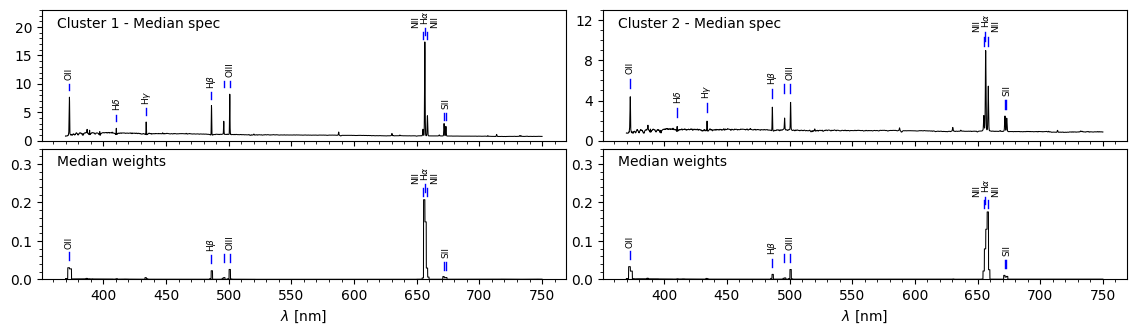

In [38]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(14, 3.5),
    sharex=True,
    sharey=False,
)

# Cluster 1
axs[0, 0].plot(wave_nm, med_spec_1, color="black", linewidth=lw)

y_lims = (0, 23)
y_ticks = np.arange(0, 23, 5)
axs[0, 0].set_ylim(y_lims)
axs[0, 0].set_yticks(y_ticks)

top_lines = {
    "indicator_starts": 1.2,
    "indicator_height": 1.2,
    "delta": 1,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_delta', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[0, 0], wave_nm, med_spec_1, **top_lines)

# weights
axs[1, 0].plot(wave_nm, med_weights_1, color="black", linewidth=lw)

bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 1,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[1, 0], wave_nm, med_weights_1, **bottom_lines)

# ------------------------------------------------------------------
# Cluster 2
axs[0, 1].plot(wave_nm, med_spec_2, color="black", linewidth=lw)

y_lims = (0, 13)
y_ticks = np.arange(0, 13, 4)
axs[0, 1].set_ylim(y_lims)
axs[0, 1].set_yticks(y_ticks)
top_lines = {
    "indicator_starts": 0.9,
    "indicator_height": 0.9,
    "delta": 1,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_delta', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[0, 1], wave_nm, med_spec_2, **top_lines)

# weights
axs[1, 1].plot(wave_nm, med_weights_2, color="black", linewidth=lw)
bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 10,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[1, 1], wave_nm, med_weights_2, **bottom_lines)
# --------------------------------------------------------------------
# lim and ticks for explanation weights
y_lims = (0, 0.34)
y_ticks = np.arange(0, 0.34, 0.1)

axs[1, 0].set_ylim(y_lims)
axs[1, 0].set_yticks(y_ticks)

axs[1, 1].set_ylim(y_lims)
axs[1, 1].set_yticks(y_ticks)
# wavelength
axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text cluster 1
axs[0, 0].text(
    0.03, 0.95, 'Cluster 1 - Median spec', transform=axs[0, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

axs[1, 0].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

# add text cluster 2
axs[0, 1].text(
    0.03, 0.95, 'Cluster 2 - Median spec', transform=axs[0, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[1, 1].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# save fig
fname = 'se_cluster_1_2'
fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

## Cluseters 3 and 4

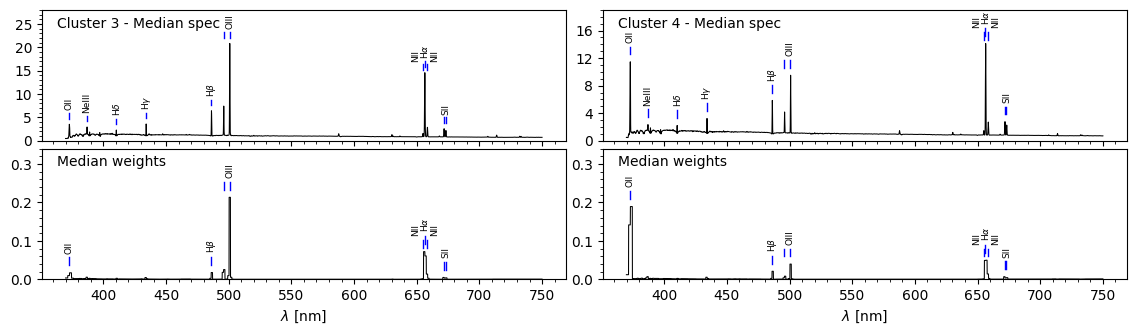

In [105]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(14, 3.5),
    sharex=True,
    sharey=False,
)

# Cluster 3
axs[0, 0].plot(wave_nm, med_spec_3, color="black", linewidth=lw)

y_lims = (0, 28)
y_ticks = np.arange(0, 28, 5)
axs[0, 0].set_ylim(y_lims)
axs[0, 0].set_yticks(y_ticks)

top_lines = {
    "indicator_starts": 1.2,
    "indicator_height": 1.2,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": [
        'OII', 'NeIII', 'H_delta', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'
    ],
}
add_line_indicators(axs[0, 0], wave_nm, med_spec_3, **top_lines)

# weights
axs[1, 0].plot(wave_nm, med_weights_3, color="black", linewidth=lw)

bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[1, 0], wave_nm, med_weights_3, **bottom_lines)

# ------------------------------------------------------------------
# Cluster 4
axs[0, 1].plot(wave_nm, med_spec_4, color="black", linewidth=lw)

y_lims = (0, 19)
y_ticks = np.arange(0, 18, 4)
axs[0, 1].set_ylim(y_lims)
axs[0, 1].set_yticks(y_ticks)

top_lines = {
    "indicator_starts": 1.1,
    "indicator_height": 1.1,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": [
        'OII', 'NeIII', 'H_delta', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'
    ],
}
add_line_indicators(axs[0, 1], wave_nm, med_spec_4, **top_lines)

# weights
axs[1, 1].plot(wave_nm, med_weights_4, color="black", linewidth=lw)
bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[1, 1], wave_nm, med_weights_4, **bottom_lines)
# --------------------------------------------------------------------
# lim and ticks for explanation weights
y_lims = (0, 0.34)
y_ticks = np.arange(0, 0.34, 0.1)

axs[1, 0].set_ylim(y_lims)
axs[1, 0].set_yticks(y_ticks)

axs[1, 1].set_ylim(y_lims)
axs[1, 1].set_yticks(y_ticks)
# wavelength
axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text cluster 3
axs[0, 0].text(
    0.03, 0.95, 'Cluster 3 - Median spec', transform=axs[0, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

axs[1, 0].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

# add text cluster 4
axs[0, 1].text(
    0.03, 0.95, 'Cluster 4 - Median spec', transform=axs[0, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[1, 1].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# # save fig
# fname = 'se_cluster_3_4'
# fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

## Figure

1
3


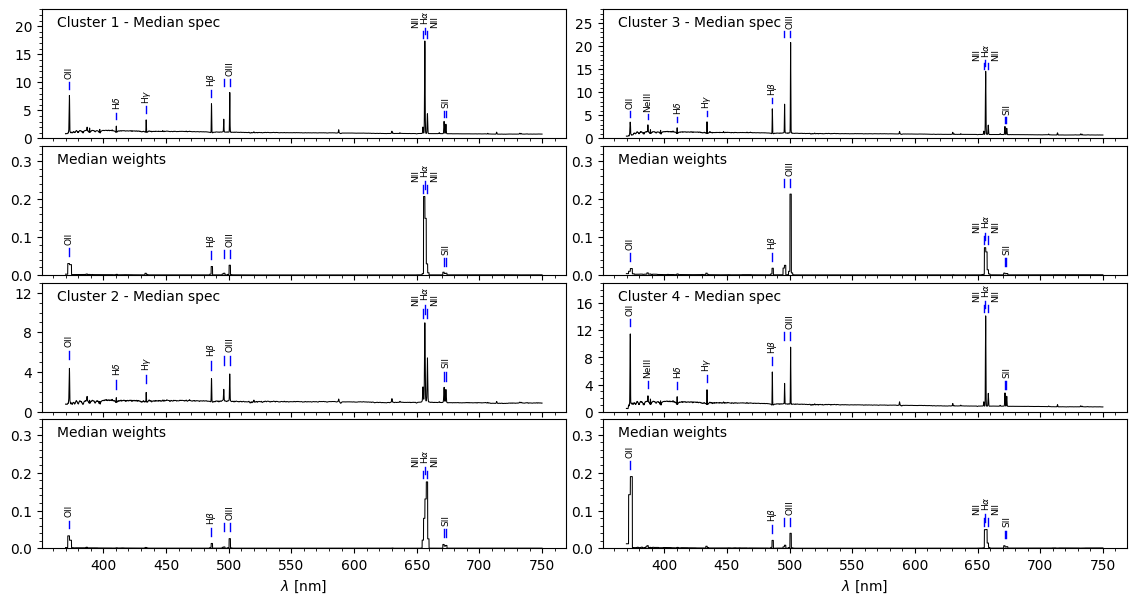

In [40]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=4, ncols=2,
    figsize=(14, 7),
    sharex=True,
    sharey=False,
)

# ------------------------------------------------------------------
# Cluster 1
axs[0, 0].plot(wave_nm, med_spec_1, color="black", linewidth=lw)

y_lims = (0, 23)
y_ticks = np.arange(0, 23, 5)
axs[0, 0].set_ylim(y_lims)
axs[0, 0].set_yticks(y_ticks)
top_lines = {
    "indicator_starts": 1.2,
    "indicator_height": 1.2,
    "delta": 1,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_delta', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[0, 0], wave_nm, med_spec_1, **top_lines)
# weights
axs[1, 0].plot(wave_nm, med_weights_1, color="black", linewidth=lw)
bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 1,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[1, 0], wave_nm, med_weights_1, **bottom_lines)
# ------------------------------------------------------------------
# Cluster 2
axs[2, 0].plot(wave_nm, med_spec_2, color="black", linewidth=lw)

y_lims = (0, 13)
y_ticks = np.arange(0, 13, 4)
axs[2, 0].set_ylim(y_lims)
axs[2, 0].set_yticks(y_ticks)
top_lines = {
    "indicator_starts": 0.9,
    "indicator_height": 0.9,
    "delta": 1,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_delta', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[2, 0], wave_nm, med_spec_2, **top_lines)
# weights
axs[3, 0].plot(wave_nm, med_weights_2, color="black", linewidth=lw)
bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 10,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[3, 0], wave_nm, med_weights_2, **bottom_lines)
# ------------------------------------------------------------------
# Cluster 3
axs[0, 1].plot(wave_nm, med_spec_3, color="black", linewidth=lw)

y_lims = (0, 28)
y_ticks = np.arange(0, 28, 5)
axs[0, 1].set_ylim(y_lims)
axs[0, 1].set_yticks(y_ticks)
top_lines = {
    "indicator_starts": 1.2,
    "indicator_height": 1.2,
    "delta": 1,
    "fontsize": 6.5,
    "active_lines": [
        'OII', 'NeIII', 'H_delta', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'
    ],
}
add_line_indicators(axs[0, 1], wave_nm, med_spec_3, **top_lines)
# weights
axs[1, 1].plot(wave_nm, med_weights_3, color="black", linewidth=lw)
bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[1, 1], wave_nm, med_weights_3, **bottom_lines)
# ------------------------------------------------------------------
# Cluster 4
axs[2, 1].plot(wave_nm, med_spec_4, color="black", linewidth=lw)

y_lims = (0, 19)
y_ticks = np.arange(0, 18, 4)
axs[2, 1].set_ylim(y_lims)
axs[2, 1].set_yticks(y_ticks)
top_lines = {
    "indicator_starts": 1.1,
    "indicator_height": 1.1,
    "delta": 1,
    "fontsize": 6.5,
    "active_lines": [
        'OII', 'NeIII', 'H_delta', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'
    ],
}
add_line_indicators(axs[2, 1], wave_nm, med_spec_4, **top_lines)
# weights
axs[3, 1].plot(wave_nm, med_weights_4, color="black", linewidth=lw)
bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
}
add_line_indicators(axs[3, 1], wave_nm, med_weights_4, **bottom_lines)
# --------------------------------------------------------------------
# lim and ticks for explanation weights
y_lims = (0, 0.34)
y_ticks = np.arange(0, 0.34, 0.1)

for i in range(0, 4, 2):
    print(i + 1)
    axs[i + 1, 0].set_ylim(y_lims)
    axs[i + 1, 0].set_yticks(y_ticks)
    axs[i + 1, 1].set_ylim(y_lims)
    axs[i + 1, 1].set_yticks(y_ticks)

# wavelength
axs[-1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[-1, 1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text
for i in range(0, 2):

    axs[i * 2, 0].text(
        0.03, 0.95, f'Cluster {i + 1} - Median spec',
        transform=axs[i * 2, 0].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )
    axs[i * 2 + 1, 0].text(
        0.03, 0.95, 'Median weights',
        # 0.03, 0.95, f'Cluster {i + 1} - Median weights',
        transform=axs[i * 2 + 1, 0].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )

    axs[i * 2, 1].text(
        0.03, 0.95, f'Cluster {i + 3} - Median spec',
        transform=axs[i * 2, 1].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )
    axs[i * 2 + 1, 1].text(
        0.03, 0.95, 'Median weights',
        # 0.03, 0.95, f'Cluster {i + 3} - Median weights',
        transform=axs[i * 2 + 1, 1].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )

plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# # save fig
# fname = 'se_cluster_1_to_4'
# fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

# SDSS class

In [41]:
# Define target row order and mapping
subclass_order = [
    "STARFORMING",
    "STARBURST",
    "STARFORMING BROADLINE",
    "STARBURST BROADLINE",
    "AGN",
    "AGN BROADLINE",
    "BROADLINE",
    "UNDEFINED",
    "Total",
]

cluster_dfs = {}
clusters = [1, 2, 3, 4]

for c_id in clusters:

    cluster_mask = cluster_meta_df["cluster"] == c_id
    metadata_df = cluster_meta_df.loc[cluster_mask]
    df_c = get_subclass_summary(metadata_df)

    # 1. Map 'nan' string / NaN values to 'UNDEFINED'
    df_c["subClass"] = df_c["subClass"].replace({"nan": "UNDEFINED", None: "UNDEFINED"})

    # 2. Set 'subClass' as index to align across clusters
    df_c = df_c.set_index("subClass")

    # 3. Ensure all categories are present, filling missing with 0
    df_c = df_c.reindex(subclass_order).fillna(0)

    # Recompute Total row to ensure accurate sums
    df_c.loc["Total", "count"] = df_c.drop("Total")["count"].sum()
    df_c.loc["Total", "pct"] = df_c.drop("Total")["pct"].sum()

    # Format counts as integers
    df_c["count"] = df_c["count"].astype(int)

    cluster_dfs[f"Cluster {c_id}"] = df_c

# 4. Concatenate with MultiIndex columns (Cluster level on top)
combined_df = pd.concat(cluster_dfs, axis=1)
combined_df.index.name = "subClass"
combined_df.to_clipboard(excel=True, index=True)
combined_df

Cluster 1           Cluster 2           Cluster 3  \
                          count       pct     count       pct     count   
subClass                                                                  
STARFORMING                  22  0.040741        29  0.100694        13   
STARBURST                   485  0.898148       166  0.576389       171   
STARFORMING BROADLINE         2  0.003704         3  0.010417         0   
STARBURST BROADLINE           6  0.011111         3  0.010417         0   
AGN                          13  0.024074        58  0.201389        70   
AGN BROADLINE                 0  0.000000        11  0.038194        11   
BROADLINE                     0  0.000000         4  0.013889         0   
UNDEFINED                    12  0.022222        14  0.048611         3   
Total                       540  1.000000       288  1.000000       268   

                                Cluster 4            
                            pct     count       pct  
subClass                                             
STARFORMING            0.048507        54  0.177632  
STARBURST              0.638060       240  0.789474  
STARFORMING BROADLINE  0.000000         0  0.000000  
STARBURST BROADLINE    0.000000         0  0.000000  
AGN                    0.261194         2  0.006579  
AGN BROADLINE          0.041045         0  0.000000  
BROADLINE              0.000000         0  0.000000  
UNDEFINED              0.011194         8  0.026316  
Total                  1.000000       304  1.000000

## Cluster 0

In [42]:
cluster_id = 0
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
sdss_class_df = get_subclass_summary(metadata_df)
sdss_class_df

,subClass,count,pct
0,nan,135,0.330882
1,STARFORMING,110,0.269608
2,STARBURST,81,0.198529
3,AGN,55,0.134804
4,AGN BROADLINE,17,0.041667
5,BROADLINE,10,0.024510
6,Total,408,1.000000


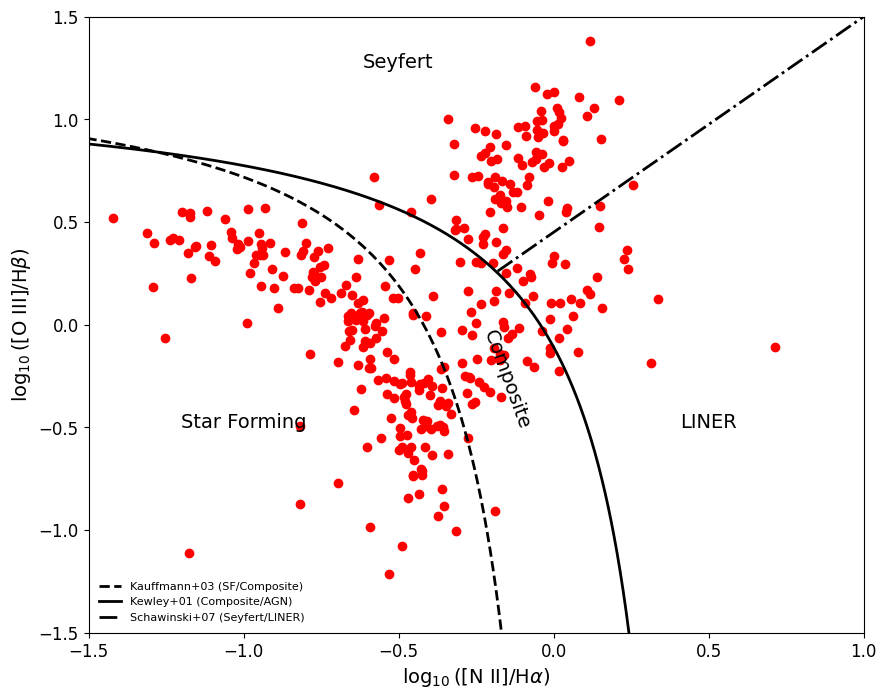

In [43]:
cluster_id = 0
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
n_anomalies_in_cluster = metadata_df.shape[0]
labels = ["" for i in range(0, n_anomalies_in_cluster)]
n2_ha = metadata_df["nii_to_halpha"].to_list()
o3_hb = metadata_df["oiii_to_hbeta"].to_list()
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)

fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = BPT.standar_bpt_plot(fig, ax, log_n2_ha, log_o3_hb, labels, xytext=(-5, 5))

## Cluster 1

In [44]:
cluster_id = 1
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
sdss_class_df = get_subclass_summary(metadata_df)
sdss_class_df

,subClass,count,pct
0,STARBURST,485,0.898148
1,STARFORMING,22,0.040741
2,AGN,13,0.024074
3,nan,12,0.022222
4,STARBURST BROADLINE,6,0.011111
5,STARFORMING BROADLINE,2,0.003704
6,Total,540,1.000000


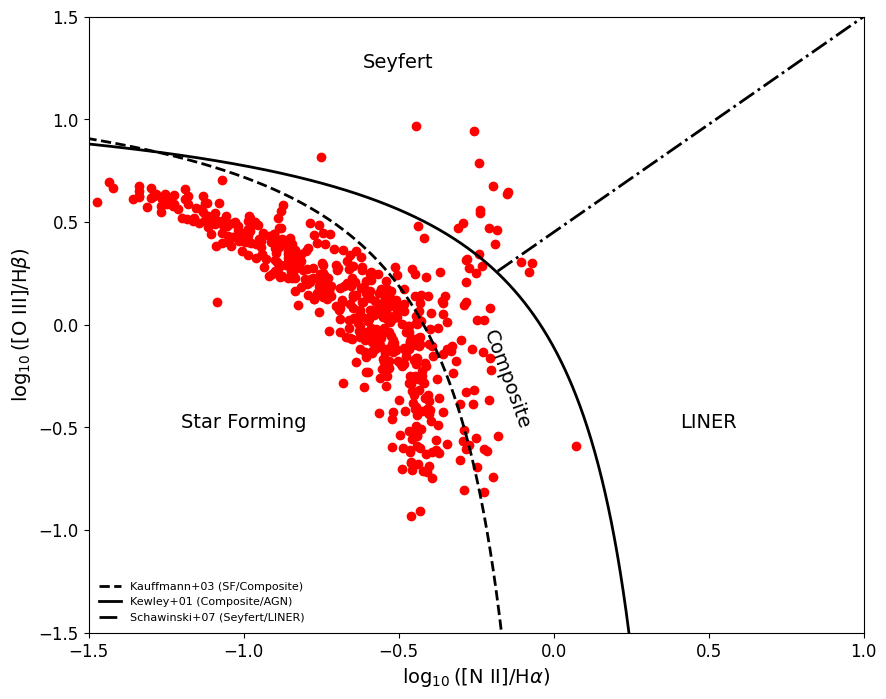

In [45]:
cluster_id = 1
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
n_anomalies_in_cluster = metadata_df.shape[0]
labels = ["" for i in range(0, n_anomalies_in_cluster)]
n2_ha = metadata_df["nii_to_halpha"].to_list()
o3_hb = metadata_df["oiii_to_hbeta"].to_list()
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)

fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = BPT.standar_bpt_plot(fig, ax, log_n2_ha, log_o3_hb, labels, xytext=(-5, 5))

## Cluster 2

In [46]:
cluster_meta_df.subClass.unique()

array([nan, 'STARBURST', 'STARFORMING', 'AGN BROADLINE', 'BROADLINE',
       'AGN', 'STARBURST BROADLINE', 'STARFORMING BROADLINE'],
      dtype=object)

In [47]:
cluster_id = 2
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
sdss_class_df = get_subclass_summary(metadata_df)
sdss_class_df

,subClass,count,pct
0,STARBURST,166,0.576389
1,AGN,58,0.201389
2,STARFORMING,29,0.100694
3,nan,14,0.048611
4,AGN BROADLINE,11,0.038194
5,BROADLINE,4,0.013889
6,STARBURST BROADLINE,3,0.010417
7,STARFORMING BROADLINE,3,0.010417
8,Total,288,1.000000


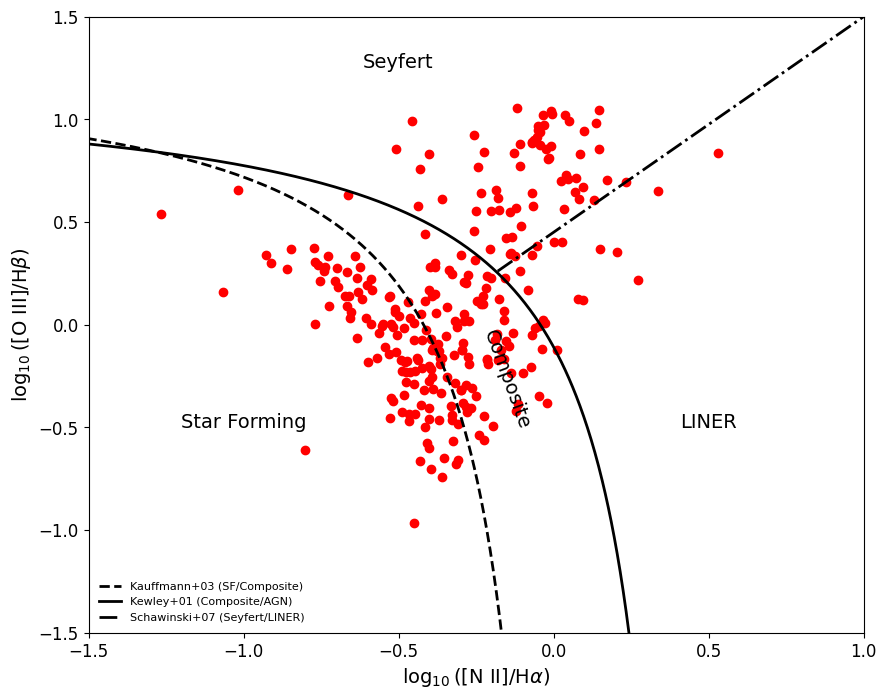

In [48]:
cluster_id = 2
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
n_anomalies_in_cluster = metadata_df.shape[0]
labels = ["" for i in range(0, n_anomalies_in_cluster)]
n2_ha = metadata_df["nii_to_halpha"].to_list()
o3_hb = metadata_df["oiii_to_hbeta"].to_list()
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)

fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = BPT.standar_bpt_plot(fig, ax, log_n2_ha, log_o3_hb, labels, xytext=(-5, 5))

## Cluster 3

In [49]:
cluster_id = 3
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
sdss_class_df = get_subclass_summary(metadata_df)
sdss_class_df

,subClass,count,pct
0,STARBURST,171,0.638060
1,AGN,70,0.261194
2,STARFORMING,13,0.048507
3,AGN BROADLINE,11,0.041045
4,nan,3,0.011194
5,Total,268,1.000000


## Cluster 4

In [50]:
cluster_id = 4
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
sdss_class_df = get_subclass_summary(metadata_df)
sdss_class_df

,subClass,count,pct
0,STARBURST,240,0.789474
1,STARFORMING,54,0.177632
2,nan,8,0.026316
3,AGN,2,0.006579
4,Total,304,1.000000


## Cluster 5

In [51]:
cluster_id = 5
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
sdss_class_df = get_subclass_summary(metadata_df)
sdss_class_df

,subClass,count,pct
0,nan,7,0.636364
1,STARFORMING,2,0.181818
2,STARBURST,1,0.090909
3,BROADLINE,1,0.090909
4,Total,11,1.000000


# Appendix Examples

## Cluster 0

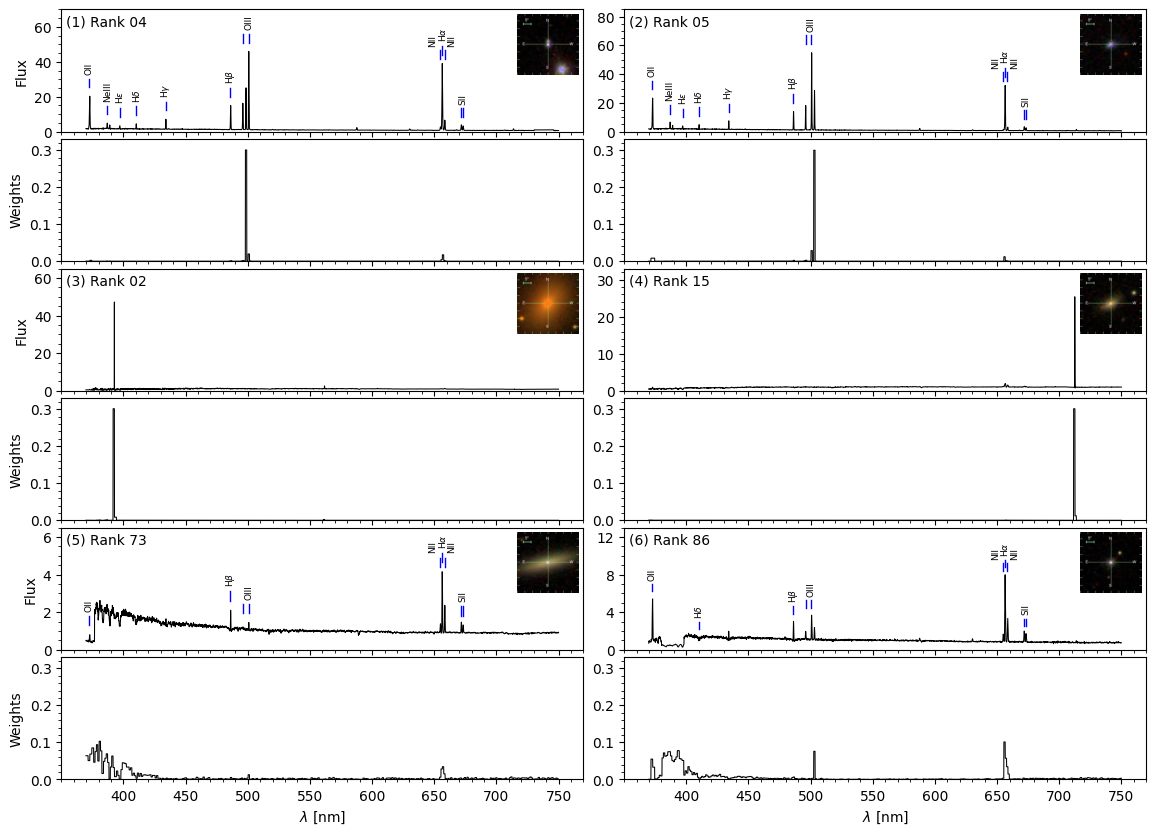

In [52]:
specobjids_dict = {
    # Clipped OIII
    4: 1767703038748813312,
    5: 1610143844655982592,
    # Spikes
    2: 1413149843194406912,
    15: 2064929367867287552,
    # data artifacts
    73: 1959139281477855232,
    86: 3127826983174563840,
}

cluster_id = 0
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)
spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]

examples_spec_dict = {}
examples_weights_dict = {}
examples_img_dict = {}

for rank, specobjid in specobjids_dict.items():

    anomaly_rank = rank - 1
    assert specobjid == metadata_df.index[anomaly_rank], (
        f"specobjid mismatch: {specobjid} != {metadata_df.index[anomaly_rank]}"
    )

    spec = spectra[anomaly_rank]
    examples_spec_dict[rank] = spec

    norm_weights_spec = norm_weights[anomaly_rank]
    examples_weights_dict[rank] = norm_weights_spec

    # Load the image
    image_name = f"image_{specobjid}.jpeg"
    img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")
    examples_img_dict[rank] = img

fig, axs = plt.subplots(6, 2, sharex=True, figsize=(14, 10))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    4: {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 70),
        "yticks": range(0, 70, 20),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    5: {
        "prefix": "(2)",
        "r": 0,
        "c": 1,
        "ylim": (0, 85),
        "yticks": range(0, 85, 20),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    2: {
        "prefix": "(3)",
        "r": 2,
        "c": 0,
        "ylim": (0, 65),
        "yticks": range(0, 65, 20),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    15: {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (0, 33),
        "yticks": range(0, 33, 10),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    73: {
        "prefix": "(5)",
        "r": 4,
        "c": 0,
        "ylim": (0, 6.5),
        "yticks": range(0, 7, 2),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    86: {
        "prefix": "(6)",
        "r": 4,
        "c": 1,
        "ylim": (0, 13),
        "yticks": range(0, 13, 4),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    4: {
        "top": {
            "indicator_starts": 5,
            "indicator_height": 5,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
    },
    2: {
        "top": {
            "indicator_starts": 1.5,
            "indicator_height": 2,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
    },
    73: {
        "top": {
            "indicator_starts": 0.5,
            "indicator_height": 0.5,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
        },
        "bot": {
            "indicator_starts": 0.5,
            "indicator_height": 0.5,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
    },
    5: {
        "top": {
            "indicator_starts": 6,
            "indicator_height": 6,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
    },
    15: {
        "top": {
            "indicator_starts": 1.5,
            "indicator_height": 2,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
    },
    86: {
        "top": {
            "indicator_starts": 0.8,
            "indicator_height": 0.8,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": ['OII', 'H_delta', 'H_beta', 'OIII', 'H_alpha', 'SII'],
        },
        "bot": {
            "indicator_starts": 0.6,
            "indicator_height": 0.6,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
    },

}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for rank, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(rank, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        examples_spec_dict[rank],
        examples_img_dict[rank],
        add_image=True,
        lw=line_width_spec,
    )
    name = f"Rank {rank:02d}"
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, examples_spec_dict[rank], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, examples_weights_dict[rank],
        lw=line_width_xai
    )
    # # abs max abs normalization of weights
    axs[r + 1, c].set_ylim(0, 0.33)
    axs[r + 1, c].set_yticks([0, 0.1, 0.2, 0.3])
    axs[r + 1, c].minorticks_on()

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1, c], wave_nm, examples_weights_dict[rank], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[-1, col].set_xlim(350, 770)
    axs[-1, col].set_xticks(wave_ticks)
    axs[-1, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)
# # Save figure
# fig.savefig(f"{ch_6_dir}/se_cluster_{cluster_id}_examples.pdf", bbox_inches="tight")

## Cluster 5

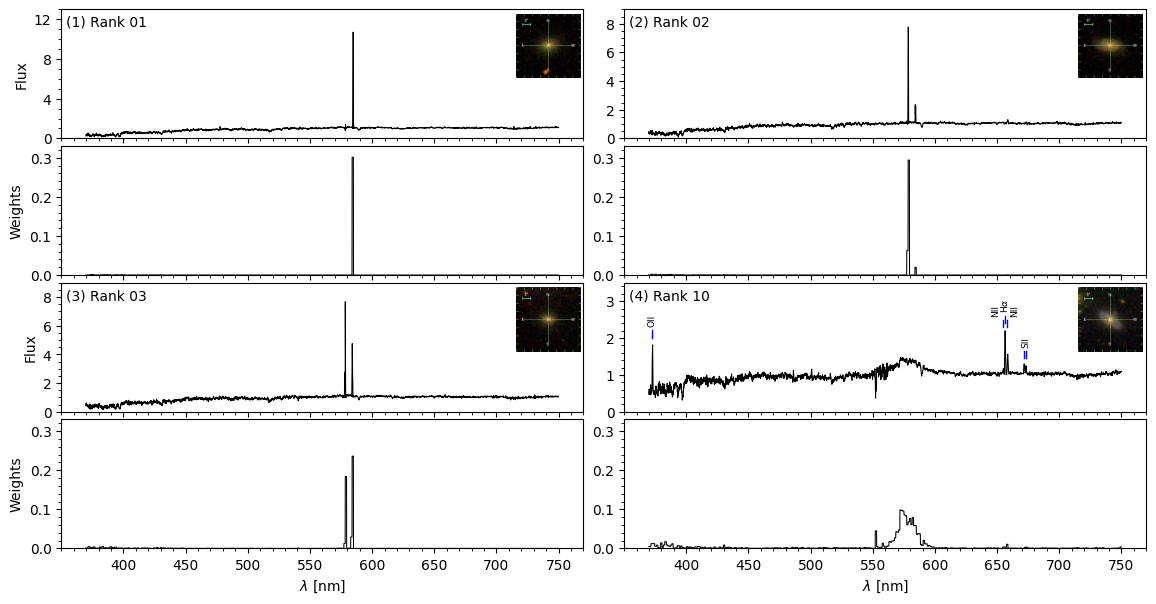

In [53]:
specobjids_dict = {
    1: 378457983132133376,
    2: 378448362405390336,
    3: 378459907277481984,
    10: 863651577993390080,
}

cluster_id = 5
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)
spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]

examples_spec_dict = {}
examples_weights_dict = {}
examples_img_dict = {}

for rank, specobjid in specobjids_dict.items():

    anomaly_rank = rank - 1
    assert specobjid == metadata_df.index[anomaly_rank], (
        f"specobjid mismatch: {specobjid} != {metadata_df.index[anomaly_rank]}"
    )

    spec = spectra[anomaly_rank]
    examples_spec_dict[rank] = spec

    norm_weights_spec = norm_weights[anomaly_rank]
    examples_weights_dict[rank] = norm_weights_spec

    # Load the image
    image_name = f"image_{specobjid}.jpeg"
    img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")
    examples_img_dict[rank] = img
# --------------------------------------------------------------------------------------
# figure
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    1: {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 13),
        "yticks": range(0, 13, 4),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    2: {
        "prefix": "(2)",
        "r": 0,
        "c": 1,
        "ylim": (0, 9),
        "yticks": range(0, 9, 2),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    3: {
        "prefix": "(3)",
        "r": 2,
        "c": 0,
        "ylim": (0, 9),
        "yticks": range(0, 9, 2),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    10: {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (0, 3.5),
        "yticks": [0, 1, 2, 3],
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    1: {
        "top": {
            "indicator_starts": 1.5,
            "indicator_height": 2,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
    },
    2: {
        "top": {
            "indicator_starts": 1.5,
            "indicator_height": 2,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
    },
    3: {
        "top": {
            "indicator_starts": 1.5,
            "indicator_height": 2,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
    },
    10: {
        "top": {
            "indicator_starts": 0.2,
            "indicator_height": 0.2,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": ['OII', 'H_alpha', 'SII'],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for rank, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(rank, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        examples_spec_dict[rank],
        examples_img_dict[rank],
        add_image=True,
        lw=line_width_spec,
    )
    name = f"Rank {rank:02d}"
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, examples_spec_dict[rank], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, examples_weights_dict[rank],
        lw=line_width_xai
    )
    # # abs max abs normalization of weights
    axs[r + 1, c].set_ylim(0, 0.33)
    axs[r + 1, c].set_yticks([0, 0.1, 0.2, 0.3])
    axs[r + 1, c].minorticks_on()

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1, c], wave_nm, examples_weights_dict[rank], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[-1, col].set_xlim(350, 770)
    axs[-1, col].set_xticks(wave_ticks)
    axs[-1, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)
# # Save figure
# fig.savefig(f"{ch_6_dir}/se_cluster_{cluster_id}_examples.pdf", bbox_inches="tight")

## Cluster 1 and 2

In [54]:
specobjids_1_dict = {

}

specobjids_2_dict = {

}

## Cluster 3

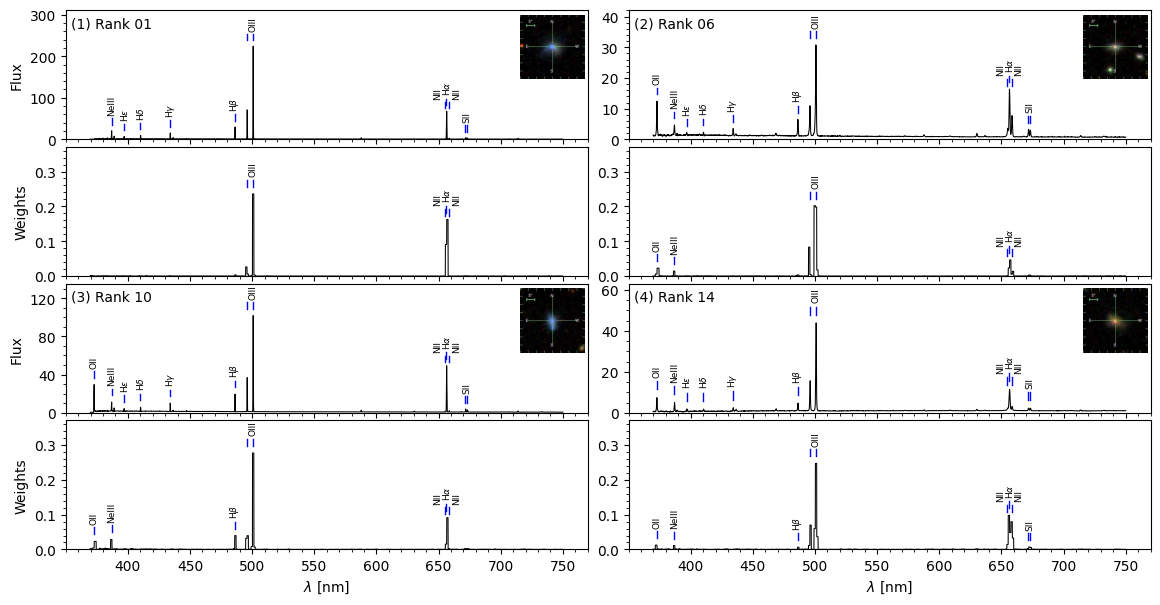

In [86]:
specobjids_dict = {
    1: 969534273977608192,
    6: 1921938144194750464,
    10: 561847176611784704,
    14: 1633733043925575680
}

cluster_id = 3
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)
spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]

examples_spec_dict = {}
examples_weights_dict = {}
examples_img_dict = {}

for rank, specobjid in specobjids_dict.items():

    anomaly_rank = rank - 1
    assert specobjid == metadata_df.index[anomaly_rank], (
        f"specobjid mismatch: {specobjid} != {metadata_df.index[anomaly_rank]}"
    )

    spec = spectra[anomaly_rank]
    examples_spec_dict[rank] = spec

    norm_weights_spec = norm_weights[anomaly_rank]
    examples_weights_dict[rank] = norm_weights_spec

    # Load the image
    image_name = f"image_{specobjid}.jpeg"
    img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")
    examples_img_dict[rank] = img

fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    1: {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 310),
        "yticks": range(0, 310, 100),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    6: {
        "prefix": "(2)",
        "r": 0,
        "c": 1,
        "ylim": (0, 42),
        "yticks": range(0, 42, 10),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    10: {
        "prefix": "(3)",
        "r": 2,
        "c": 0,
        "ylim": (0, 135),
        "yticks": range(0, 135, 40),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    14: {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (0, 63),
        "yticks": range(0, 65, 20),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    1: {
        "top": {
            "indicator_starts": 15,
            "indicator_height": 15,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [
                'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": ['OIII', 'H_alpha'],
        },
    },
    6: {
        "top": {
            "indicator_starts": 2.2,
            "indicator_height": 2.2,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'NeIII', 'OIII', 'H_alpha'],
        },
    },
    10: {
        "top": {
            "indicator_starts": 7,
            "indicator_height": 7,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": ['OII', 'NeIII', 'H_beta', 'OIII', 'H_alpha'],
        },
    },
    14: {
        "top": {
            "indicator_starts": 4,
            "indicator_height": 4,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": ['OII', 'NeIII', 'H_beta', 'OIII', 'H_alpha', 'SII'],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for rank, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(rank, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        examples_spec_dict[rank],
        examples_img_dict[rank],
        add_image=True,
        lw=line_width_spec,
    )
    name = f"Rank {rank:02d}"
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, examples_spec_dict[rank], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, examples_weights_dict[rank],
        lw=line_width_xai
    )
    # # abs max abs normalization of weights
    axs[r + 1, c].set_ylim(0, 0.37)
    axs[r + 1, c].set_yticks([0, 0.1, 0.2, 0.3])
    axs[r + 1, c].minorticks_on()

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1, c], wave_nm, examples_weights_dict[rank], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[-1, col].set_xlim(350, 770)
    axs[-1, col].set_xticks(wave_ticks)
    axs[-1, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)
# Save figure
fig.savefig(f"{ch_6_dir}/se_cluster_{cluster_id}_examples.pdf", bbox_inches="tight")

## Cluster 4

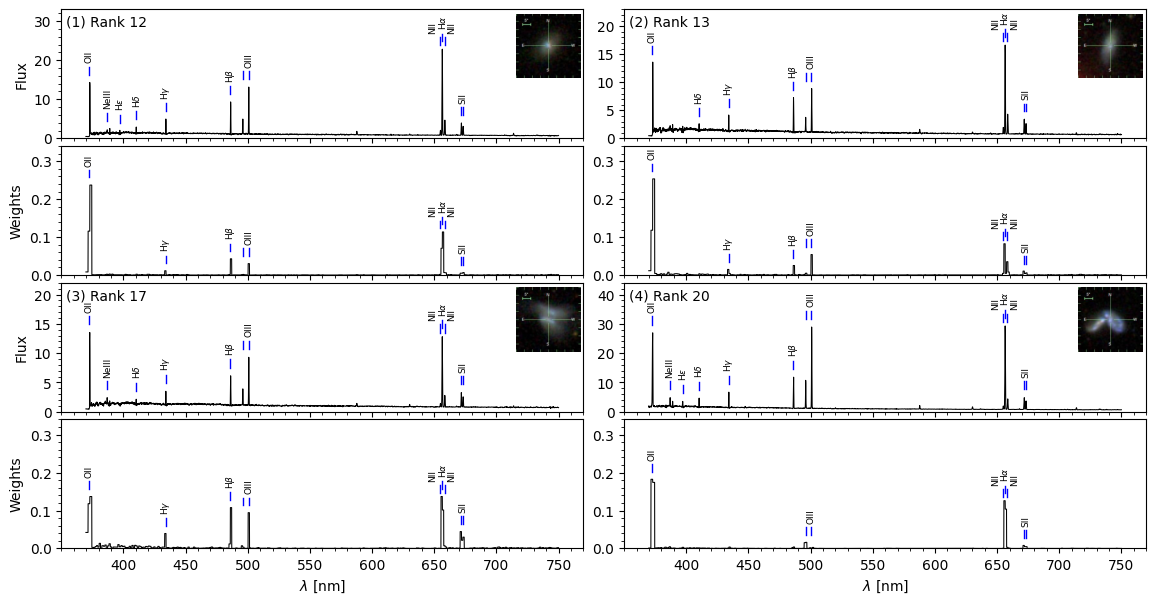

In [ ]:
specobjids_dict = {
    12: 954854150368159744,
    13: 1628112614741534720,
    17: 2032359622903359488,
    20: 3096237184492005376
}

cluster_id = 4
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)
spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]

examples_spec_dict = {}
examples_weights_dict = {}
examples_img_dict = {}

for rank, specobjid in specobjids_dict.items():

    anomaly_rank = rank - 1
    assert specobjid == metadata_df.index[anomaly_rank], (
        f"specobjid mismatch: {specobjid} != {metadata_df.index[anomaly_rank]}"
    )

    spec = spectra[anomaly_rank]
    examples_spec_dict[rank] = spec

    norm_weights_spec = norm_weights[anomaly_rank]
    examples_weights_dict[rank] = norm_weights_spec

    # Load the image
    image_name = f"image_{specobjid}.jpeg"
    img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")
    examples_img_dict[rank] = img

fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    12: {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 33),
        "yticks": range(0, 33, 10),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    13: {
        "prefix": "(2)",
        "r": 0,
        "c": 1,
        "ylim": (0, 23),
        "yticks": range(0, 23, 5),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    17: {
        "prefix": "(3)",
        "r": 2,
        "c": 0,
        "ylim": (0, 22),
        "yticks": range(0, 22, 5),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    20: {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (0, 44),
        "yticks": range(0, 44, 10),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    12: {
        "top": {
            "indicator_starts": 2,
            "indicator_height": 2,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma',
                'H_beta', 'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'],
        },
    },
    13: {
        "top": {
            "indicator_starts": 1.4,
            "indicator_height": 1.4,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'H_delta', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'],
        },
    },
    17: {
        "top": {
            "indicator_starts": 1.4,
            "indicator_height": 1.4,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_delta', 'H_gamma',
                'H_beta', 'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', "SII"],
        },
    },
    20: {
        "top": {
            "indicator_starts": 2.8,
            "indicator_height": 2.8,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'OIII', 'H_alpha', 'SII'],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for rank, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(rank, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        examples_spec_dict[rank],
        examples_img_dict[rank],
        add_image=True,
        lw=line_width_spec,
    )
    name = f"Rank {rank:02d}"
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, examples_spec_dict[rank], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, examples_weights_dict[rank],
        lw=line_width_xai
    )
    # # abs max abs normalization of weights
    axs[r + 1, c].set_ylim(0, 0.34)
    axs[r + 1, c].set_yticks([0, 0.1, 0.2, 0.3])
    axs[r + 1, c].minorticks_on()

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1, c], wave_nm, examples_weights_dict[rank], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[-1, col].set_xlim(350, 770)
    axs[-1, col].set_xticks(wave_ticks)
    axs[-1, col].set_xlabel(r"$\lambda$ [nm]")

# plt.subplots_adjust(hspace=0.06, wspace=0.078)
# # Save figure
# fig.savefig(f"{ch_6_dir}/se_cluster_{cluster_id}_examples.pdf", bbox_inches="tight")